# Análises comparativas de algoritmos

Este notebook propõe análises interessantes para comparar algoritmos no desafio SBPO 2025.

As análises usam os arquivos de resumo em `results/*/summary_*.csv` e o baseline em `best_solutions/best_objectives.csv`.

## Ideias de análise incluídas

1. **Cobertura de viabilidade e timeout** por algoritmo (confiabilidade).
2. **Gap relativo para o melhor conhecido** por instância e dataset.
3. **Fronteira eficiência x qualidade** (objetivo médio vs tempo médio).
4. **Robustez entre execuções** com variância/desvio do objetivo.
5. **Estabilidade de ranking** por instância e ranking agregado.
6. **Sensibilidade por tamanho de instância** (quando disponível em metadados).

In [1]:
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 180)

In [2]:
# 1) Carrega todos os summaries disponíveis
summary_paths = sorted(glob.glob('../results/*/summary_*.csv'))
if not summary_paths:
    raise FileNotFoundError('Nenhum arquivo summary_*.csv encontrado em ../results/*')

summaries = [pd.read_csv(path) for path in summary_paths]
df = pd.concat(summaries, ignore_index=True)

# 2) Carrega o melhor conhecido por instância
best = pd.read_csv('../best_solutions/best_objectives.csv')

# 3) Enriquecimento para análises
df = df.merge(best, on=['dataset', 'instance'], how='left')
df['gap_to_best_pct'] = np.where(
    df['best_objective'] > 0,
    100.0 * (df['best_objective'] - df['objective_mean']) / df['best_objective'],
    np.nan,
)
df['feasible_rate'] = np.where(df['total_runs'] > 0, df['feasible_runs'] / df['total_runs'], np.nan)
df['timeout_rate'] = np.where(df['total_runs'] > 0, df['timed_out_runs'] / df['total_runs'], np.nan)

print(f'Resumos carregados: {len(summary_paths)}')
print(f'Linhas: {len(df)} | Algoritmos: {df.algorithm.nunique()} | Instâncias: {df.instance.nunique()}')
df.head(3)

Resumos carregados: 1
Linhas: 206 | Algoritmos: 15 | Instâncias: 20


,dataset,algorithm,instance,total_runs,feasible_runs,timed_out_runs,objective_mean,objective_median,objective_mode,objective_min,objective_max,objective_variance,objective_std_dev,items_mean,items_median,items_mode,items_min,items_max,items_variance,items_std_dev,aisles_mean,aisles_median,aisles_mode,aisles_min,aisles_max,aisles_variance,aisles_std_dev,exec_time_mean,exec_time_median,exec_time_mode,exec_time_min,exec_time_max,exec_time_variance,exec_time_std_dev,best_objective,gap_to_best_pct,feasible_rate,timeout_rate
0,a,aisle_cluster_expansion,instance_0001.txt,1,1,0,15.00,15.00,15.00,15.00,15.00,0.0,0.0,45.0,45.0,45,45,45,0.0,0.0,3.0,3.0,3,3,3,0.0,0.0,0.114049,0.114049,0.114049,0.114049,0.114049,0.0,0.0,15.0,0.000000,1.0,0.0
1,a,aisle_cluster_expansion,instance_0002.txt,1,1,0,2.00,2.00,2.00,2.00,2.00,0.0,0.0,2.0,2.0,2,2,2,0.0,0.0,1.0,1.0,1,1,1,0.0,0.0,0.000514,0.000514,0.000514,0.000514,0.000514,0.0,0.0,2.0,0.000000,1.0,0.0
2,a,aisle_cluster_expansion,instance_0003.txt,1,1,0,8.75,8.75,8.75,8.75,8.75,0.0,0.0,35.0,35.0,35,35,35,0.0,0.0,4.0,4.0,4,4,4,0.0,0.0,0.248051,0.248051,0.248051,0.248051,0.248051,0.0,0.0,12.0,27.083333,1.0,0.0


## 1) Confiabilidade: viabilidade e timeout

In [3]:
reliability = (
    df.groupby('algorithm', as_index=False)
      .agg(
          feasible_rate_mean=('feasible_rate', 'mean'),
          timeout_rate_mean=('timeout_rate', 'mean'),
      )
      .sort_values(['feasible_rate_mean', 'timeout_rate_mean'], ascending=[False, True])
)
reliability

,algorithm,feasible_rate_mean,timeout_rate_mean
0,aisle_cluster_expansion,1.000000,0.000000
1,aisle_first_asc,1.000000,0.000000
2,aisle_first_desc,1.000000,0.000000
3,aisle_first_random,1.000000,0.000000
4,column_generation,1.000000,0.000000
5,diff,1.000000,0.000000
6,diff_multi,1.000000,0.000000
7,greedy_set_cover,1.000000,0.000000
9,lp_aisle_focus,1.000000,0.000000
10,min_aisle_cover,1.000000,0.000000


## 2) Qualidade: gap para melhor conhecido (quanto menor, melhor)

In [4]:
gap_summary = (
    df.groupby(['dataset', 'algorithm'], as_index=False)
      .agg(
          avg_gap_pct=('gap_to_best_pct', 'mean'),
          median_gap_pct=('gap_to_best_pct', 'median'),
      )
      .sort_values(['dataset', 'avg_gap_pct'])
)
gap_summary

,dataset,algorithm,avg_gap_pct,median_gap_pct
7,a,greedy_set_cover,8.222222,0.000000
0,a,aisle_cluster_expansion,8.931560,0.000000
4,a,column_generation,9.730942,3.689018
9,a,lp_aisle_focus,10.812158,4.436860
2,a,aisle_first_desc,11.727622,12.467174
3,a,aisle_first_random,11.814453,12.467174
1,a,aisle_first_asc,11.996789,12.578782
8,a,lagrangian_relaxation,15.775308,20.000000
10,a,min_aisle_cover,35.727711,35.558176
14,a,simple_multi,72.346104,84.111133


## 3) Eficiência: objetivo médio vs tempo médio (fronteira de Pareto)

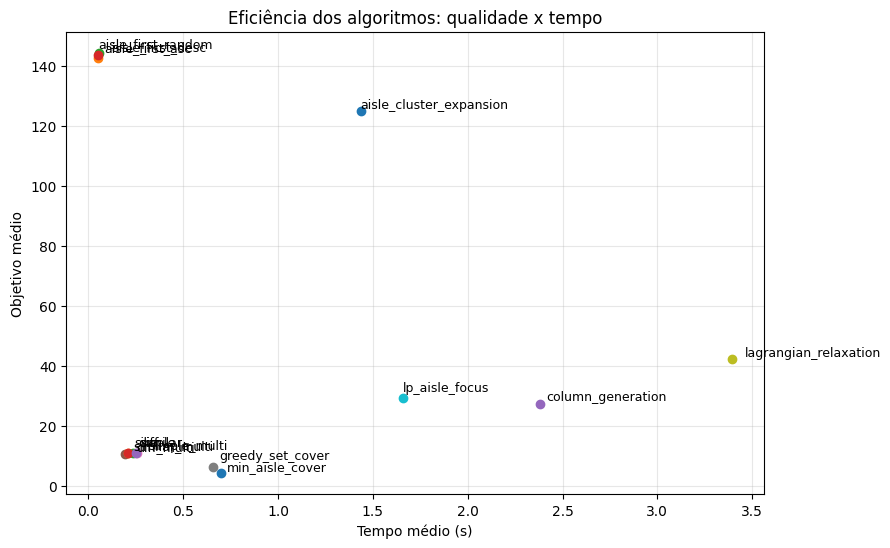

In [5]:
eff = (
    df.groupby('algorithm', as_index=False)
      .agg(
          objective_mean=('objective_mean', 'mean'),
          exec_time_mean=('exec_time_mean', 'mean'),
      )
)

x_range = max(eff['exec_time_mean'].max() - eff['exec_time_mean'].min(), 1e-9)
y_range = max(eff['objective_mean'].max() - eff['objective_mean'].min(), 1e-9)

plt.figure(figsize=(9, 6))
for idx, row in eff.iterrows():
    plt.scatter(row['exec_time_mean'], row['objective_mean'])
    dx = 0.01 * x_range * (idx % 3)
    dy = 0.01 * y_range * (idx % 2)
    plt.text(row['exec_time_mean'] + dx, row['objective_mean'] + dy, row['algorithm'], ha='left', va='bottom', fontsize=9)

plt.xlabel('Tempo médio (s)')
plt.ylabel('Objetivo médio')
plt.title('Eficiência dos algoritmos: qualidade x tempo')
plt.grid(alpha=0.3)
plt.show()

## 4) Robustez: variabilidade do objetivo

In [6]:
robustness = (
    df.groupby('algorithm', as_index=False)
      .agg(
          objective_std_mean=('objective_std_dev', 'mean'),
          objective_var_mean=('objective_variance', 'mean'),
      )
      .sort_values('objective_std_mean')
)
robustness

,algorithm,objective_std_mean,objective_var_mean
0,aisle_cluster_expansion,0.0,0.0
1,aisle_first_asc,0.0,0.0
2,aisle_first_desc,0.0,0.0
3,aisle_first_random,0.0,0.0
4,column_generation,0.0,0.0
5,diff,0.0,0.0
6,diff_multi,0.0,0.0
7,greedy_set_cover,0.0,0.0
8,lagrangian_relaxation,0.0,0.0
9,lp_aisle_focus,0.0,0.0


## 5) Ranking composto (qualidade + confiabilidade + tempo)

In [7]:
score = df.groupby('algorithm', as_index=False).agg(
    objective=('objective_mean', 'mean'),
    gap=('gap_to_best_pct', 'mean'),
    feasible=('feasible_rate', 'mean'),
    timeout=('timeout_rate', 'mean'),
    time=('exec_time_mean', 'mean'),
)

# Rank 1 = melhor para cada métrica
score['r_objective'] = score['objective'].rank(ascending=False, method='average')
score['r_gap'] = score['gap'].rank(ascending=True, method='average')
score['r_feasible'] = score['feasible'].rank(ascending=False, method='average')
score['r_timeout'] = score['timeout'].rank(ascending=True, method='average')
score['r_time'] = score['time'].rank(ascending=True, method='average')

# Menor score final = melhor algoritmo (média ponderada de posições)
score['final_rank_score'] = (
    0.40 * score['r_objective'] +
    0.25 * score['r_gap'] +
    0.20 * score['r_feasible'] +
    0.10 * score['r_timeout'] +
    0.05 * score['r_time']
)

final_ranking = score.sort_values('final_rank_score')
final_ranking

,algorithm,objective,gap,feasible,timeout,time,r_objective,r_gap,r_feasible,r_timeout,r_time,final_rank_score
2,aisle_first_desc,144.121667,11.727622,1.000000,0.000000,0.053150,1.0,5.0,7.5,7.5,3.0,4.05
3,aisle_first_random,143.521667,11.814453,1.000000,0.000000,0.051652,2.0,6.0,7.5,7.5,2.0,4.65
0,aisle_cluster_expansion,124.715909,8.931560,1.000000,0.000000,1.435321,4.0,2.0,7.5,7.5,12.0,4.95
1,aisle_first_asc,142.428333,11.996789,1.000000,0.000000,0.049354,3.0,7.0,7.5,7.5,1.0,5.25
9,lp_aisle_focus,29.141270,10.812158,1.000000,0.000000,1.657066,6.0,4.0,7.5,7.5,13.0,6.30
4,column_generation,27.352143,9.730942,1.000000,0.000000,2.382374,7.0,3.0,7.5,7.5,14.0,6.50
14,simple_multi,11.096818,72.346104,1.000000,0.000000,0.249710,8.0,10.0,7.5,7.5,8.0,8.35
7,greedy_set_cover,6.366667,8.222222,1.000000,0.000000,0.658706,14.0,1.0,7.5,7.5,10.0,8.60
8,lagrangian_relaxation,42.199584,15.775308,0.961538,0.038462,3.393586,5.0,8.0,15.0,15.0,15.0,9.25
12,similar_multi,11.061165,74.939096,1.000000,0.000000,0.235932,9.0,13.0,7.5,7.5,7.0,9.45


## Próximos passos sugeridos

- Repetir as análises separando por dataset (`a`, `b`, `x`).
- Criar gráficos por instância para detectar algoritmos especialistas.
- Adicionar testes estatísticos (Wilcoxon/Friedman + pós-teste) para comparar pares de algoritmos.
- Incluir custo computacional total (tempo x taxa de timeout) para cenários de produção.